In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [1]:
from pymongo import MongoClient
import pandas as pd

# Connect to MongoDB (local example)
client = MongoClient("mongodb://localhost:27017/")

# Select your database and collection
db = client["Energydb"]               # your database name
collection = db["Energy_consumption"]          # your collection name

# Fetch all data from MongoDB
data = list(collection.find())

# Convert to pandas DataFrame
df = pd.DataFrame(data)

# Optional: remove MongoDB’s internal _id column
if "_id" in df.columns:
    df.drop(columns=["_id"], inplace=True)

# Preview your data
df.head()




,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.36,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [3]:
df.columns

Index(['Date', 'Time', 'Global_active_power', 'Global_reactive_power',
       'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2',
       'Sub_metering_3'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   object 
 1   Time                   object 
 2   Global_active_power    object 
 3   Global_reactive_power  object 
 4   Voltage                object 
 5   Global_intensity       object 
 6   Sub_metering_1         object 
 7   Sub_metering_2         object 
 8   Sub_metering_3         float64
dtypes: float64(1), object(8)
memory usage: 142.5+ MB


In [6]:
df.notnull().sum()

Date                     2075259
Time                     2075259
Global_active_power      2075259
Global_reactive_power    2075259
Voltage                  2075259
Global_intensity         2075259
Sub_metering_1           2075259
Sub_metering_2           2075259
Sub_metering_3           2049280
dtype: int64

In [7]:
df.isnull().sum()

Date                         0
Time                         0
Global_active_power          0
Global_reactive_power        0
Voltage                      0
Global_intensity             0
Sub_metering_1               0
Sub_metering_2               0
Sub_metering_3           25979
dtype: int64

In [12]:

df.replace('?', np.nan, inplace=True) 
df = df.fillna(0)

In [13]:
df.isnull().sum()

Date                     0
Time                     0
Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
dtype: int64

In [14]:
cols_to_numeric = ['Global_active_power', 'Global_reactive_power', 'Voltage',
                   'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3'] 

for col in cols_to_numeric:
    
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   object 
 1   Time                   object 
 2   Global_active_power    float64
 3   Global_reactive_power  float64
 4   Voltage                float64
 5   Global_intensity       float64
 6   Sub_metering_1         float64
 7   Sub_metering_2         float64
 8   Sub_metering_3         float64
dtypes: float64(7), object(2)
memory usage: 142.5+ MB


In [17]:
df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], format='%d/%m/%Y %H:%M:%S')
df = df.set_index('Datetime')

In [18]:
df.drop(columns=['Date', 'Time'], inplace=True, errors='ignore')


In [19]:
df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [20]:
df.describe()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
count,2.075259e+06,2.075259e+06,2.075259e+06,2.075259e+06,2.075259e+06,2.075259e+06,2.075259e+06
mean,1.077950e+00,1.221658e-01,2.378249e+02,4.569827e+00,1.107879e+00,1.282265e+00,6.377598e+00
std,1.057642e+00,1.128556e-01,2.697024e+01,4.446361e+00,6.115669e+00,5.787271e+00,8.414871e+00
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,3.040000e-01,4.600000e-02,2.388900e+02,1.400000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,5.780000e-01,1.000000e-01,2.409600e+02,2.600000e+00,0.000000e+00,0.000000e+00,1.000000e+00
75%,1.520000e+00,1.920000e-01,2.428600e+02,6.400000e+00,0.000000e+00,1.000000e+00,1.700000e+01
max,1.112200e+01,1.390000e+00,2.541500e+02,4.840000e+01,8.800000e+01,8.000000e+01,3.100000e+01


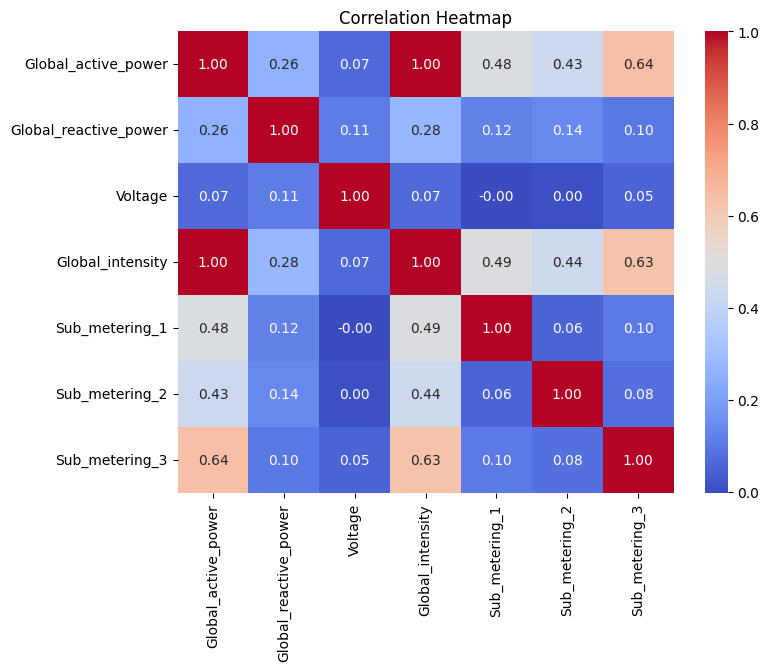

In [21]:
plt.figure(figsize=(8,6))
sns.heatmap(df[cols_to_numeric].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

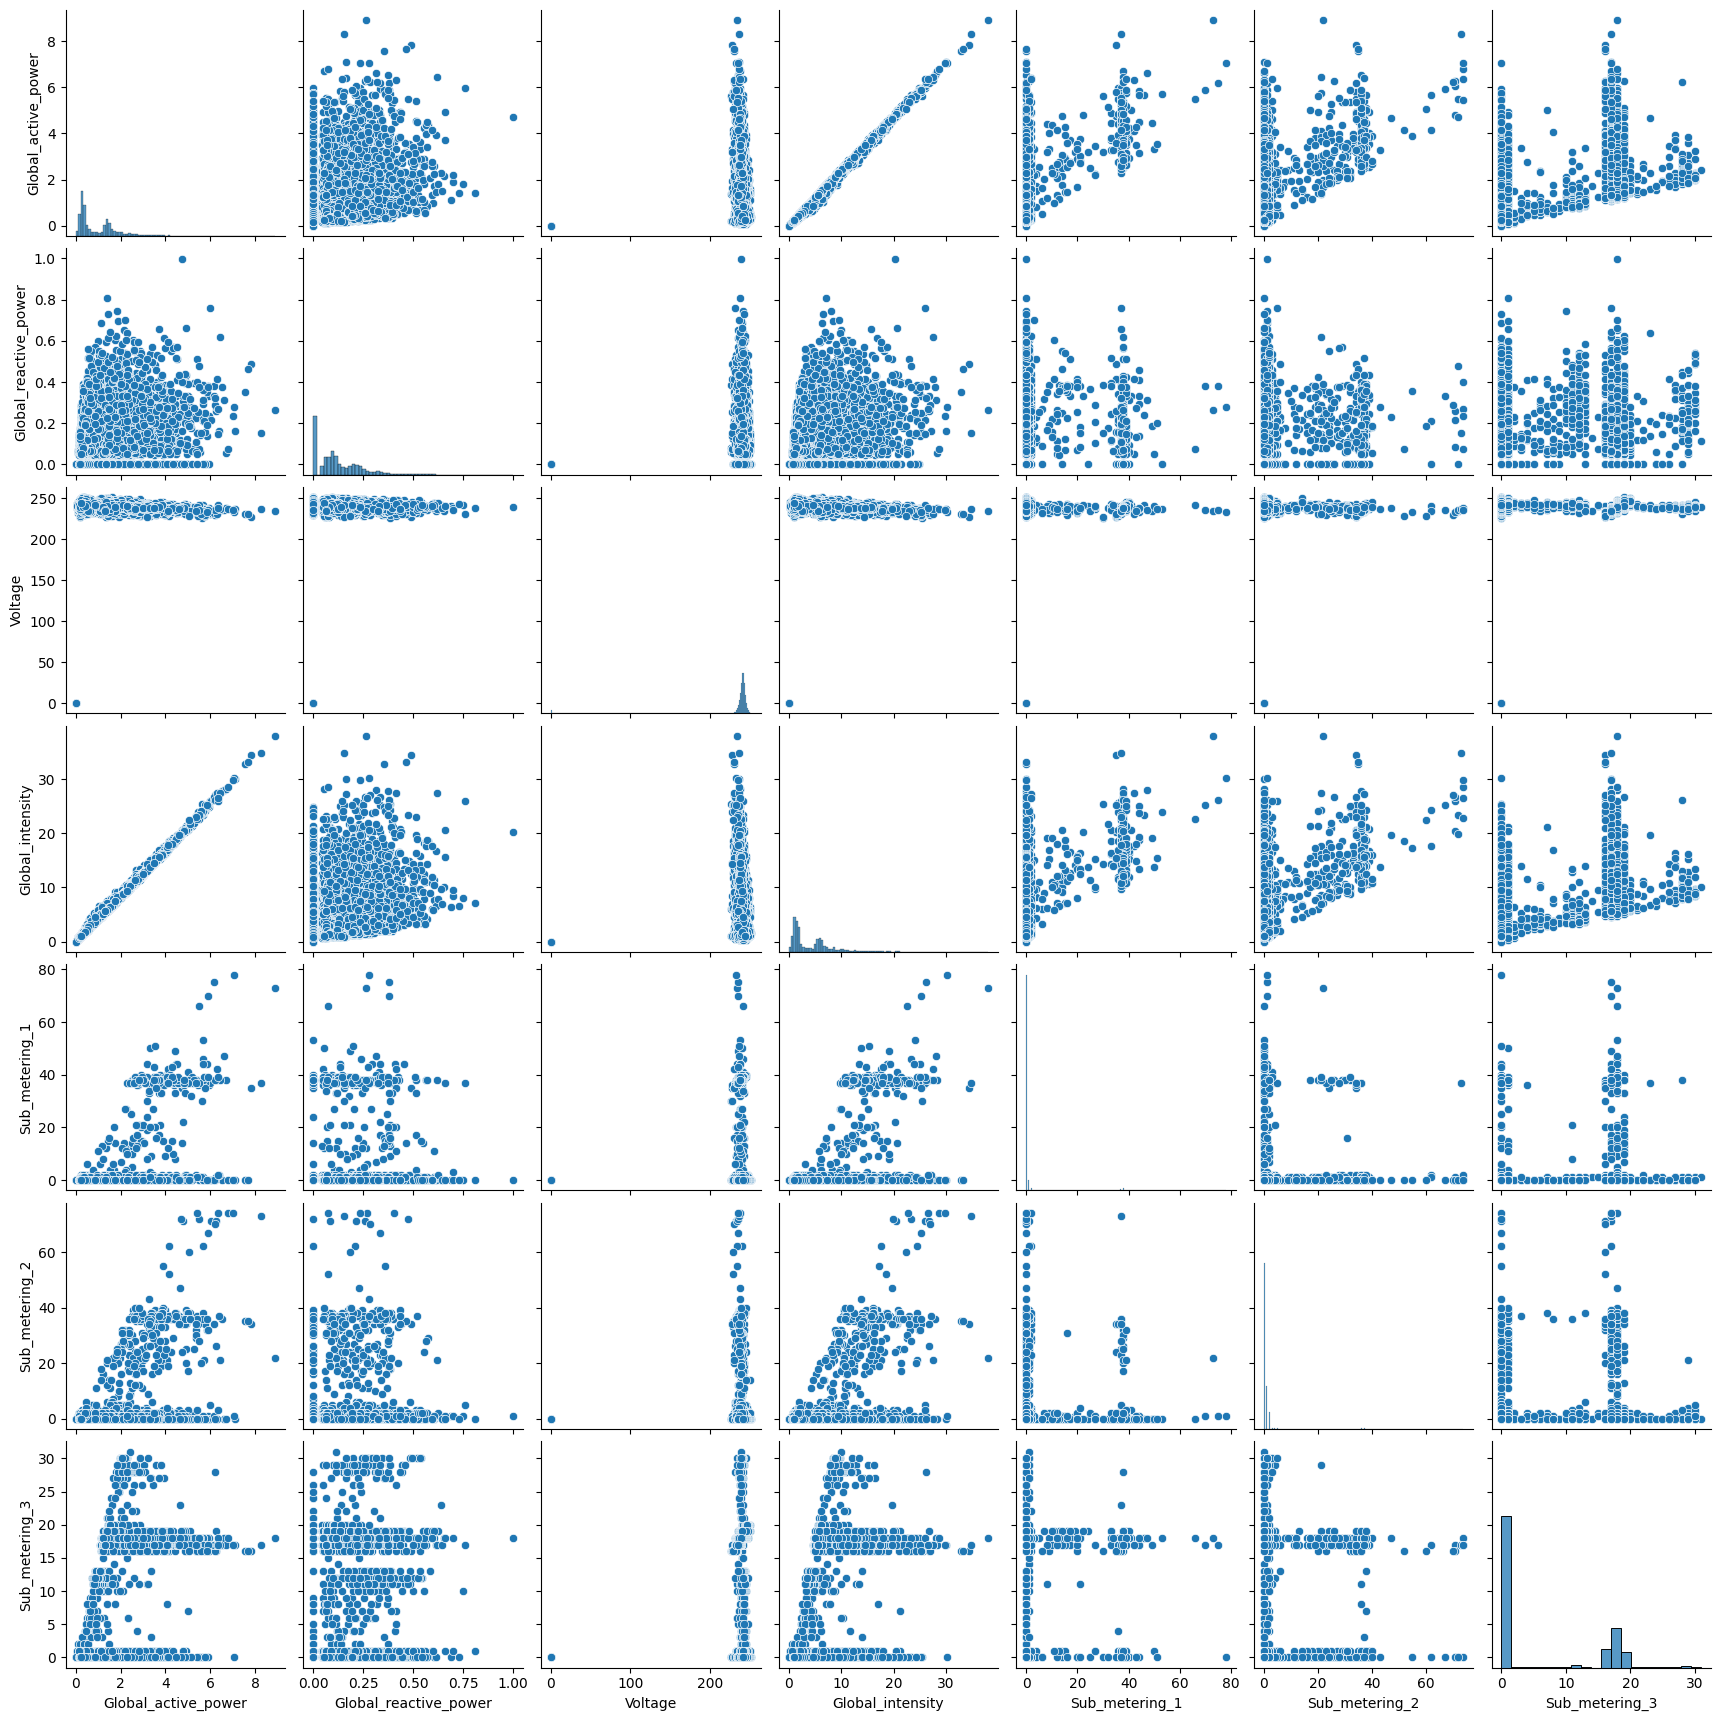

In [22]:
df_pp = df.sample(10000)  
sns.pairplot(df_pp)
plt.show()

In [24]:
hourly_hour = df.groupby(df.index.hour).mean(numeric_only=True)
hourly_hour

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,
0,0.652044,0.113685,239.685092,2.775443,0.360294,0.549167,2.933403
1,0.532963,0.103729,238.867760,2.284788,0.246021,0.393269,2.324185
2,0.474945,0.103859,239.728135,2.040537,0.144136,0.345998,2.003227
3,0.439556,0.101820,239.787935,1.894638,0.066956,0.345882,1.671883
4,0.437980,0.098270,239.222376,1.886604,0.046519,0.329632,1.841603
5,0.447377,0.095597,238.734431,1.922167,0.035207,0.311312,2.106107
6,0.780604,0.101272,238.580393,3.323102,0.038885,0.329655,4.178117
7,1.481813,0.108480,236.661186,6.237786,0.301053,0.496241,10.597791
8,1.441330,0.109338,236.277493,6.057534,1.353296,0.996229,12.487243


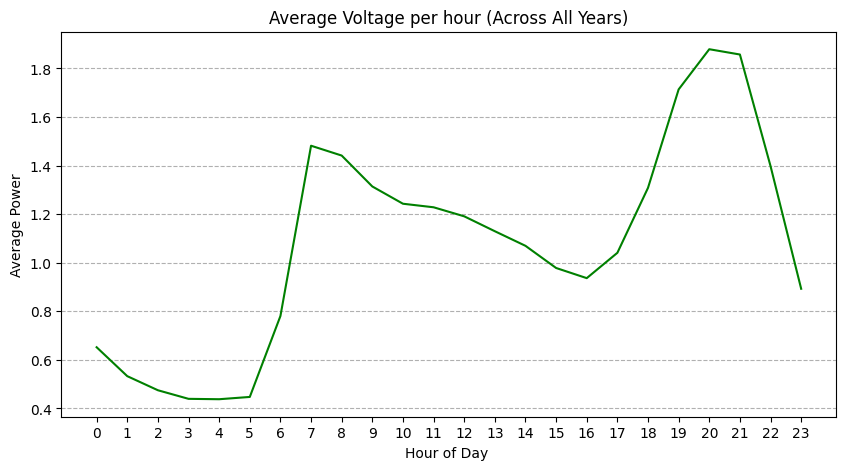

In [25]:
plt.figure(figsize=(10, 5))
plt.plot(hourly_hour.index, hourly_hour['Global_active_power'], color='green')
plt.title("Average Voltage per hour (Across All Years)")
plt.xlabel("Hour of Day ")
plt.ylabel("Average Power")
plt.xticks(range(24))
plt.grid(axis='y', linestyle='--')
plt.show()

In [27]:
daily_avg = df.resample('D').mean()
daily_avg

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,
2006-12-16,3.053475,0.088187,236.243763,13.082828,0.000000,1.378788,12.439394
2006-12-17,2.354486,0.156949,240.087028,9.999028,1.411806,2.907639,9.264583
2006-12-18,1.530435,0.112356,241.231694,6.421667,0.738194,1.820139,9.734722
2006-12-19,1.157079,0.104821,241.999313,4.926389,0.582639,5.279167,4.303472
2006-12-20,1.545658,0.111804,242.308062,6.467361,0.000000,1.838889,9.765972
...,...,...,...,...,...,...,...
2010-11-22,1.417733,0.098857,240.197118,6.014167,3.371528,1.465278,7.038889
2010-11-23,1.095511,0.095451,240.575528,4.674444,1.299306,0.318056,5.285417
2010-11-24,1.247394,0.091986,240.030965,5.249583,0.761111,1.977778,8.488889


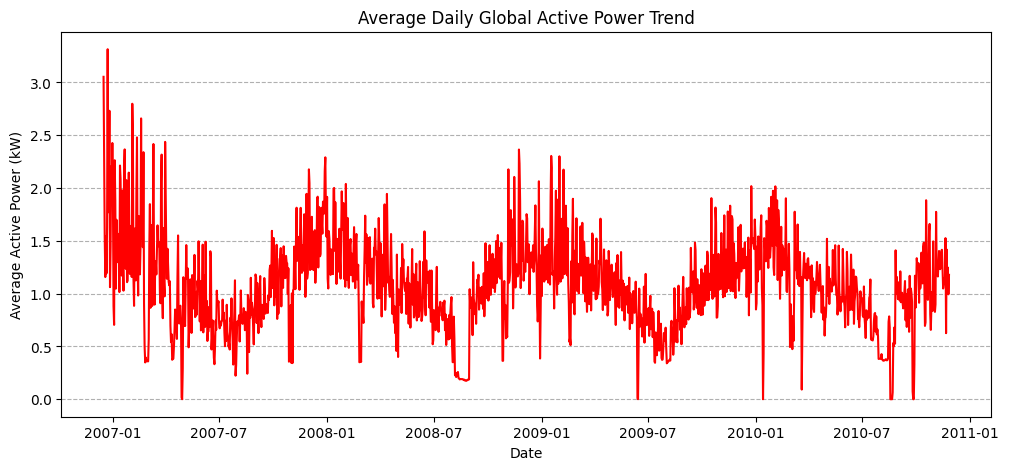

In [28]:
plt.figure(figsize=(12, 5))
plt.plot(daily_avg.index, daily_avg['Global_active_power'], label='Average Daily Active Power', color='red')
plt.title("Average Daily Global Active Power Trend")
plt.xlabel("Date")
plt.ylabel("Average Active Power (kW)")
plt.grid(axis='y', linestyle='--')
plt.show()

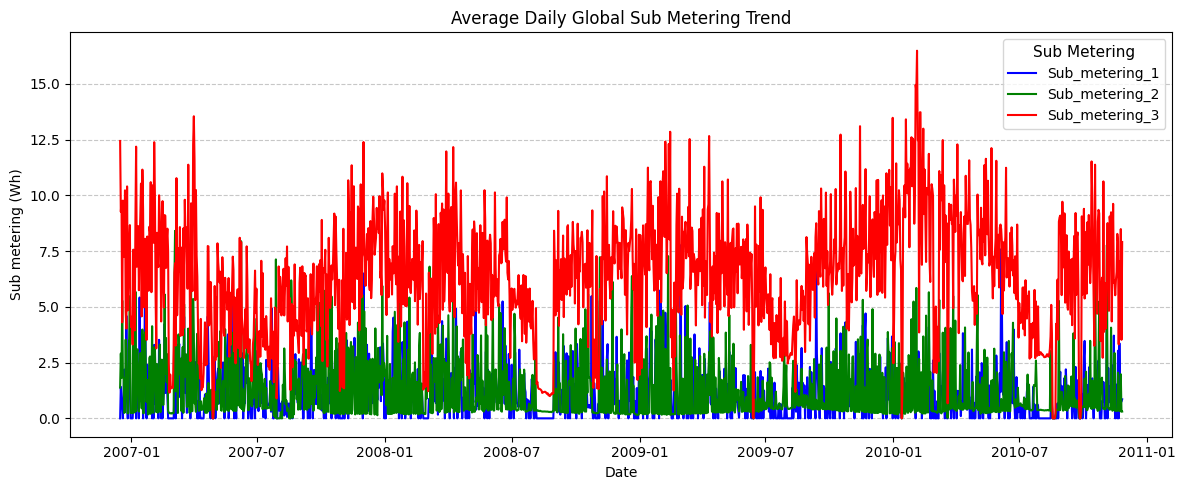

In [29]:
plt.figure(figsize=(12, 5))

plt.plot(daily_avg.index, daily_avg['Sub_metering_1'], label='Sub_metering_1', color='blue', marker='o', markersize=0)
plt.plot(daily_avg.index, daily_avg['Sub_metering_2'], label='Sub_metering_2', color='green', marker='s', markersize=0)
plt.plot(daily_avg.index, daily_avg['Sub_metering_3'], label='Sub_metering_3', color='red', marker='^', markersize=0)

plt.title("Average Daily Global Sub Metering Trend")
plt.xlabel("Date")
plt.ylabel("Sub metering (Wh)")

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.legend(title="Sub Metering", loc='upper right', fontsize=10, title_fontsize=11)

plt.tight_layout()
plt.show()
